# ANALYSES FOR THE OUTPUTS OF THE MODEL

In [54]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torchinfo
from torchinfo import summary
from torchview import draw_graph
import graphviz

# Drawing Model Summary

In [ ]:
import efficientUnet

In [51]:
# Create model summary

model = efficientUnet.EfficientUNet(in_channels=7, num_classes=7)
summary = summary(model, input_size=(1, 7, 128, 128), depth=4,
                  col_names=["input_size", "output_size", "num_params", "trainable"])

# Save the model summary to a text file
output_file = Path("model_summary.txt")
with output_file.open("w") as f:
    f.write(str(summary))
print(summary)

Layer (type:depth-idx)                             Input Shape               Output Shape              Param #                   Trainable
EfficientUNet                                      [1, 7, 128, 128]          [1, 7, 128, 128]          --                        True
├─EfficientNetFeatures: 1-1                        [1, 7, 128, 128]          [1, 24, 64, 64]           --                        True
│    └─Conv2d: 2-1                                 [1, 7, 128, 128]          [1, 40, 64, 64]           2,520                     True
│    └─BatchNormAct2d: 2-2                         [1, 40, 64, 64]           [1, 40, 64, 64]           80                        True
│    │    └─Identity: 3-1                          [1, 40, 64, 64]           [1, 40, 64, 64]           --                        --
│    │    └─SiLU: 3-2                              [1, 40, 64, 64]           [1, 40, 64, 64]           --                        --
│    └─Sequential: 2-3                             --        

In [60]:
graph = draw_graph(
    model,
    input_size=(1, 7, 128, 128),
    expand_nested=False,  # Collapse nested modules
    depth=4,
    graph_name="EfficientUNet",
    roll=True,
    save_graph=False
)

graph.visual_graph.attr(rankdir="TB")  # Top to Bottom
graph.visual_graph.attr(fontsize="8")
graph.visual_graph.attr('node', shape='box', style='rounded,filled', fillcolor='lightgray', fontsize="8", width="0.4", height="0.2")

graph.visual_graph.render("efficientunet_graph", format="pdf", cleanup=True)



'efficientunet_graph.pdf'

# Validation Metrics

In [4]:
path = Path(r'/home/sabrina/Documents/GitHub/projectsUFV/outputs_20250629_004907/training_log.csv')

df = pd.read_csv(path)

In [5]:
df_train = df.loc[df["phase"] == "train"]
df_val   = df.loc[df["phase"] == "val"]

In [10]:
sns.set_theme(style="whitegrid")

<Figure size 1600x600 with 0 Axes>

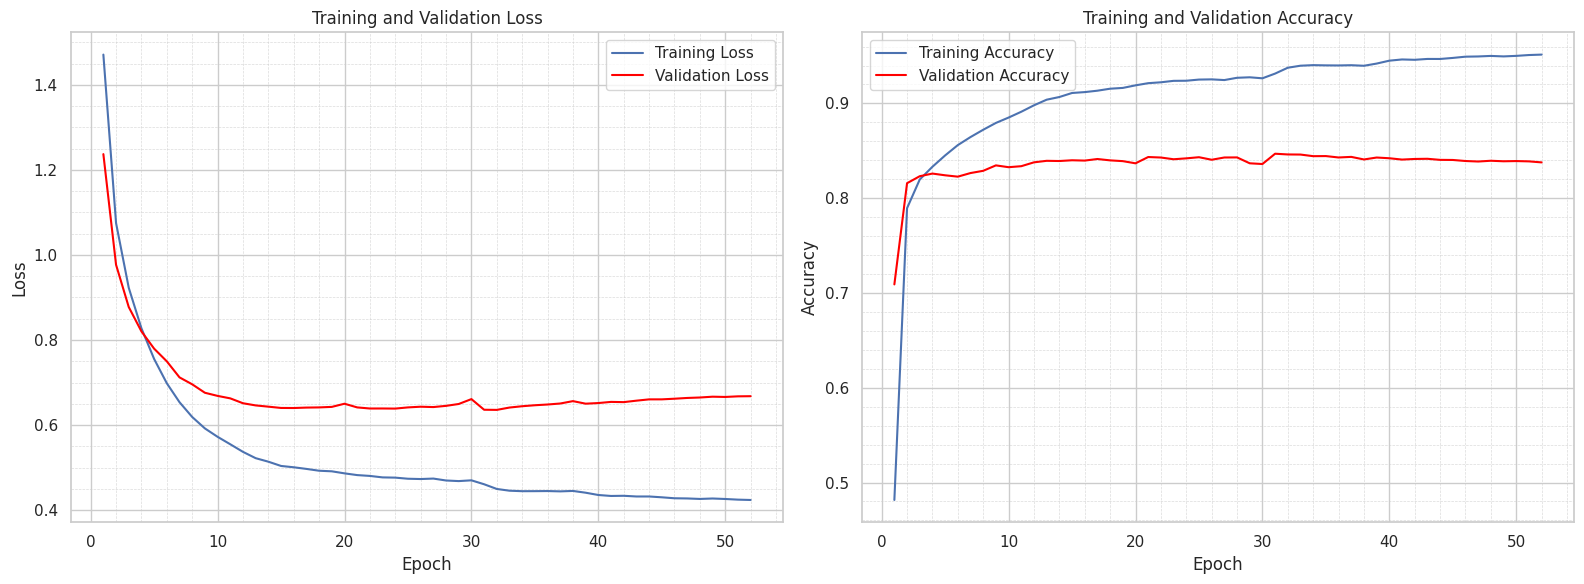

In [38]:
# Create plots for training and validation loss

plt.figure(figsize=(16,6))

fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=False)


sns.lineplot(data=df_train, x="epoch", y="loss", markers="o",  label="Training Loss", ax = ax[0])
sns.lineplot(data=df_val, x="epoch", y="loss", markers="x", label="Validation Loss", ax = ax[0], color='red')
ax[0].set_title("Training and Validation Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

# Create plots for training and validation accuracy
sns.lineplot(data=df_train, x="epoch", y="accuracy", markers="o", label="Training Accuracy", ax = ax[1])
sns.lineplot(data=df_val, x="epoch", y="accuracy", markers="x", label="Validation Accuracy", ax = ax[1], color='red')
ax[1].set_title("Training and Validation Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()

# Add minor ticks to both axes
ax[0].minorticks_on()
ax[1].minorticks_on()

# Set gridlines for major and minor ticks
ax[0].grid(True, which='major', linestyle='-', linewidth=1)
ax[0].grid(True, which='minor', linestyle='--', linewidth=0.5, alpha=0.7)

ax[1].grid(True, which='major', linestyle='-', linewidth=1)
ax[1].grid(True, which='minor', linestyle='--', linewidth=0.5, alpha=0.7)

# Adjust layout and show the plot
plt.tight_layout()

# Save the figure
output_path = Path(path.parent, r'loss_accuracy.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight', transparent=True)
# Save fig as pdf
output_path_pdf = output_path.with_suffix('.pdf')
plt.savefig(output_path_pdf, dpi=300, bbox_inches='tight', transparent=True)

plt.show()